In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/tommachilez/virag4fc.git
%cd /content/virag4fc/

Cloning into 'fact-checking-data-framework-vn'...
remote: Enumerating objects: 574, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 574 (delta 155), reused 119 (delta 65), pack-reused 344 (from 1)
Receiving objects: 100% (574/574), 5.37 MiB | 10.23 MiB/s, done.
Resolving deltas: 100% (379/379), done.
/content/fact-checking-data-framework-vn


In [ ]:
cross_encoder_scores = "/content/drive/MyDrive/KLTN_Project/Datasets/MS_MARCO/cross-encoder-ms-marco-MiniLM-L-6-v2-scores.pkl.gz"

In [ ]:
import gzip
import pickle

# Load the gzipped pickle file defined in the previous cell
with gzip.open(cross_encoder_scores, 'rb') as f:
    data = pickle.load(f)

In [ ]:
# Access the first item based on the data structure
if isinstance(data, list):
    first_item = data[0]
    print("Data structure: List")
elif isinstance(data, dict):
    # Get the first item (value) from the dictionary
    first_key = next(iter(data))
    first_item = data[first_key]
    print(f"Data structure: Dictionary (First key: {first_key})")
else:
    first_item = None
    print(f"Data structure: {type(data)}")

# Count keys if the first item is a dictionary
if isinstance(first_item, dict):
    num_keys = len(first_item)
    print(f"Number of keys in the nested dictionary of the first line: {num_keys}")
else:
    print("The first item is not a dictionary.")

Data structure: Dictionary (First key: 571018)
Number of keys in the nested dictionary of the first line: 141


In [ ]:
first_item.values()

dict_values([10.257501602172852, 3.5812907218933105, 8.257364273071289, 8.866464614868164, 5.258519172668457, 4.193713188171387, 8.563857078552246, 4.907355785369873, 7.617893695831299, 1.5268436670303345, -0.6152520179748535, -2.9456772804260254, 10.018341064453125, 10.202350616455078, 1.7948371171951294, 8.693719863891602, 4.469407081604004, 0.4720204472541809, -1.00309157371521, 1.8172178268432617, 1.7467658519744873, -1.4857474565505981, 4.076294422149658, -1.777407169342041, -0.7370984554290771, 4.278080463409424, -1.0950472354888916, 2.5531094074249268, 10.004817008972168, 10.176589965820312, 8.594615936279297, 1.8897120952606201, 7.299615859985352, 8.61693000793457, 0.10016749799251556, 6.883630752563477, 10.320749282836914, 0.7852426171302795, 2.7261080741882324, 2.0838329792022705, 1.8327460289001465, -0.6380012035369873, 0.926922082901001, 4.037473201751709, 2.498434543609619, 1.148393154144287, 0.13919004797935486, 3.2860398292541504, 10.097441673278809, 2.575753688812256, 1

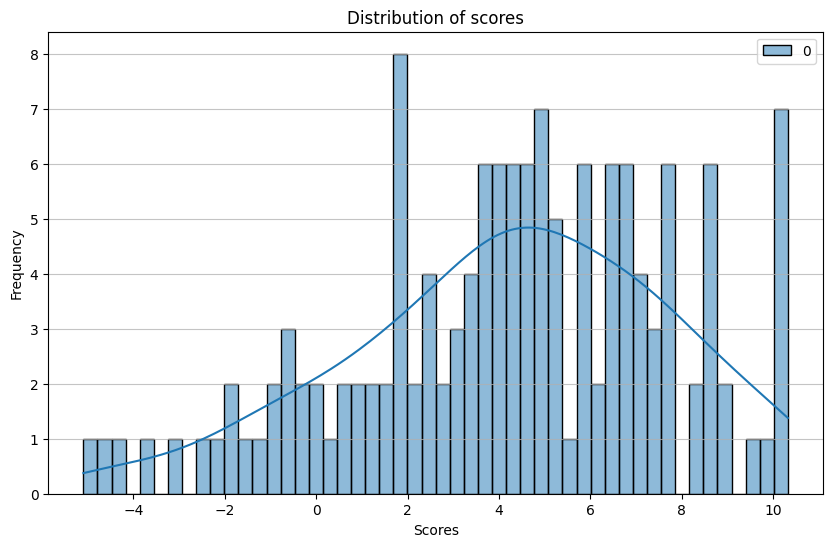

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(first_item.values(), bins=50, kde=True)
plt.title('Distribution of scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import statistics

if isinstance(data, dict):
    # Extract the number of keys for each nested dictionary
    lengths = [len(value) for value in data.values() if isinstance(value, dict)]

    if lengths:
        max_len = max(lengths)
        min_len = min(lengths)
        mean_len = statistics.mean(lengths)

        print(f"Max number of keys: {max_len}")
        print(f"Min number of keys: {min_len}")
        print(f"Mean number of keys: {mean_len:.2f}")
    else:
        print("No nested dictionaries found or data is empty.")
else:
    print("Data is not a dictionary, cannot perform this analysis.")

Max number of keys: 588
Min number of keys: 55
Mean number of keys: 197.95


# Scoring

In [12]:
dataset_path = "/content/drive/MyDrive/KLTN_Project/Datasets"
doc_mapping = f"{dataset_path}/unique_doc_mapping.csv"
query_mapping = f"{dataset_path}/updated_unique_query_mapping.csv"
training_triples = f"{dataset_path}/training_triples.jsonl"
output_dir = f"{dataset_path}/viranker_original_scores"

In [ ]:
!python -m src.scripts.filtering.score_viranker \
    --doc_mapping {doc_mapping} \
    --query_mapping {query_mapping} \
    --mining_jsonl {training_triples} \
    --output_dir {output_dir} \
    --batch_size 32 \
    # --append

Loading ViRanker from checkpoint: namdp-ptit/ViRanker on cuda...
Output Mode: Raw Logits
2025-12-25 14:09:35.927912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766671775.947431    3664 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766671775.953223    3664 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766671775.968174    3664 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766671775.968200    3664 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once

In [ ]:
!python -m src.scripts.filtering.score_viranker \
    --doc_mapping {doc_mapping} \
    --query_mapping {query_mapping} \
    --mining_jsonl {training_triples} \
    --output_dir {output_dir} \
    --batch_size 32 \
    --maxp
    # --append